In [1]:
import pandas as pd
import sqlite3
import numpy as np
from scipy.stats import linregress

In [2]:
conn = sqlite3.connect("../data/db/bluestock_mf.db")

In [3]:
query = """
SELECT name
FROM sqlite_master
WHERE type='table';
"""

tables = pd.read_sql(query, conn)

print(tables)

                name
0           dim_fund
1           fact_nav
2  fact_transactions
3   fact_performance
4           fact_aum


In [4]:
nav = pd.read_sql(
    "SELECT * FROM fact_nav",
    conn
)

print(nav.columns)
nav.head()

Index(['amfi_code', 'date', 'nav'], dtype='str')


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [5]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [6]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [7]:
nav.head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


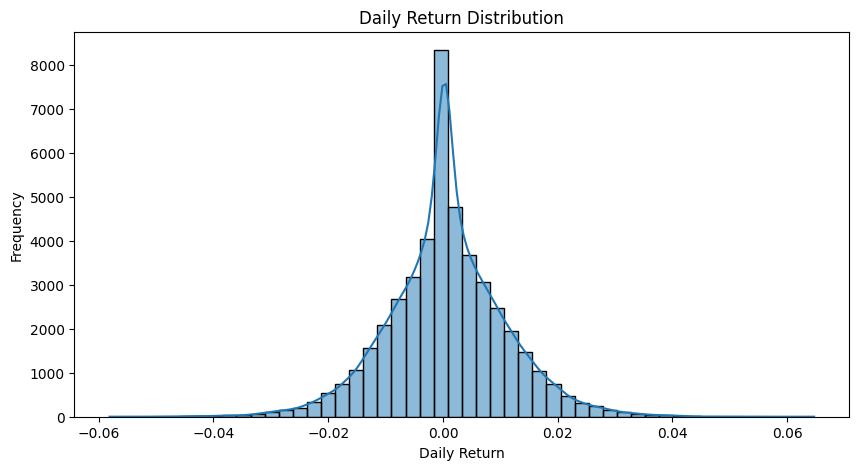

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=50,
    kde=True
)

plt.title("Daily Return Distribution")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

### Insight 1
Daily returns are centered around zero with limited extreme fluctuations, indicating stable NAV movements and a realistic return distribution across mutual fund schemes.

In [10]:
cagr_results = []

for fund in nav["amfi_code"].unique():

    fund_nav = nav[nav["amfi_code"] == fund].sort_values("date")

    start_nav = fund_nav.iloc[0]["nav"]
    end_nav = fund_nav.iloc[-1]["nav"]

    years = (
        (fund_nav.iloc[-1]["date"] -
         fund_nav.iloc[0]["date"]).days
    ) / 365

    cagr = ((end_nav / start_nav) ** (1 / years) - 1) * 100

    cagr_results.append(
        [fund, round(cagr, 2)]
    )

cagr_df = pd.DataFrame(
    cagr_results,
    columns=["amfi_code", "cagr_pct"]
)

cagr_df.sort_values(
    "cagr_pct",
    ascending=False
).head()

,amfi_code,cagr_pct
25,120505,32.80
21,119598,32.40
39,149324,32.26
36,148569,31.92
34,148567,30.95


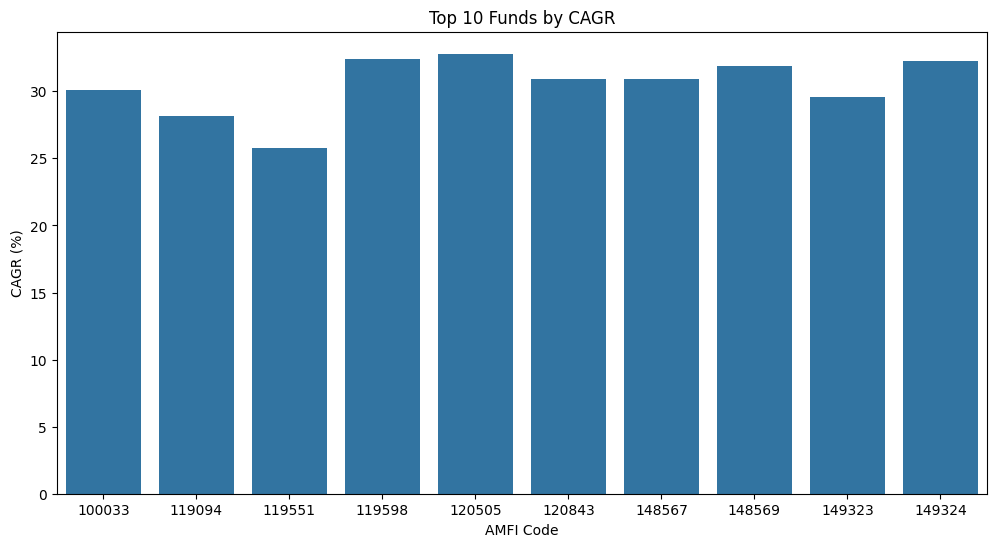

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

top10 = cagr_df.sort_values(
    "cagr_pct",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x="amfi_code",
    y="cagr_pct"
)

plt.title("Top 10 Funds by CAGR")
plt.xlabel("AMFI Code")
plt.ylabel("CAGR (%)")

plt.show()

### Insight 2
Top-performing funds generated significantly higher annualized returns, indicating strong long-term growth potential compared to peer schemes.

In [12]:
rf = 0.065

sharpe_results = []

for fund in nav["amfi_code"].unique():

    fund_data = nav[nav["amfi_code"] == fund]

    returns = fund_data["daily_return"].dropna()

    annual_return = returns.mean() * 252
    annual_volatility = returns.std() * np.sqrt(252)

    sharpe = (annual_return - rf) / annual_volatility

    sharpe_results.append(
        [fund, sharpe]
    )

sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=["amfi_code", "sharpe_ratio"]
)

sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
).head()

,amfi_code,sharpe_ratio
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101


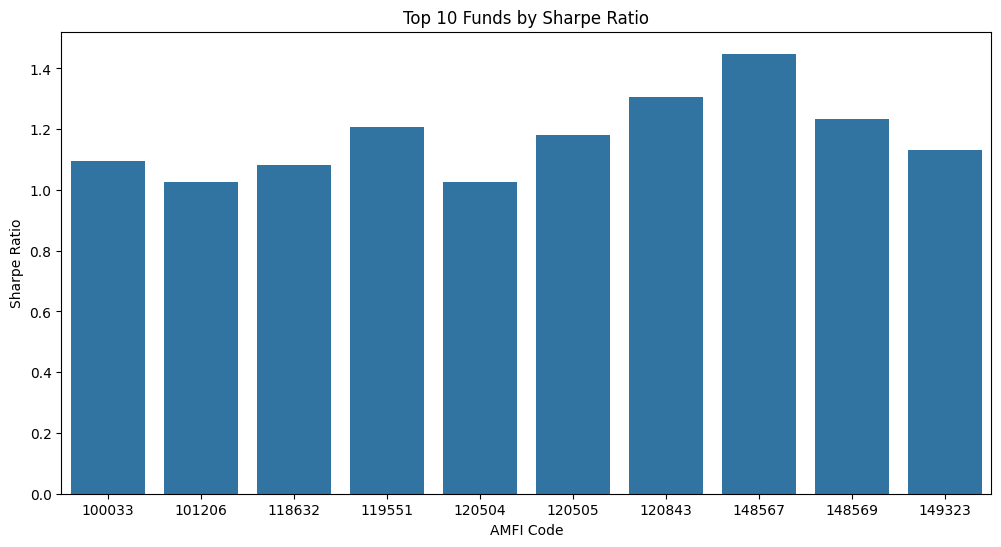

In [13]:
top10_sharpe = sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10_sharpe,
    x="amfi_code",
    y="sharpe_ratio"
)

plt.title("Top 10 Funds by Sharpe Ratio")
plt.xlabel("AMFI Code")
plt.ylabel("Sharpe Ratio")

plt.show()

### Insight 3
Funds with higher Sharpe ratios delivered superior risk-adjusted returns, generating greater returns for each unit of risk taken.

In [14]:
sortino_results = []

for fund in nav["amfi_code"].unique():

    fund_data = nav[nav["amfi_code"] == fund]

    returns = fund_data["daily_return"].dropna()

    downside_returns = returns[returns < 0]

    annual_return = returns.mean() * 252

    downside_std = downside_returns.std() * np.sqrt(252)

    sortino = (annual_return - rf) / downside_std

    sortino_results.append(
        [fund, sortino]
    )

sortino_df = pd.DataFrame(
    sortino_results,
    columns=["amfi_code", "sortino_ratio"]
)

sortino_df.sort_values(
    "sortino_ratio",
    ascending=False
).head()

,amfi_code,sortino_ratio
34,148567,2.385644
30,120843,2.364320
36,148569,2.146914
19,119551,2.140267
25,120505,2.029353


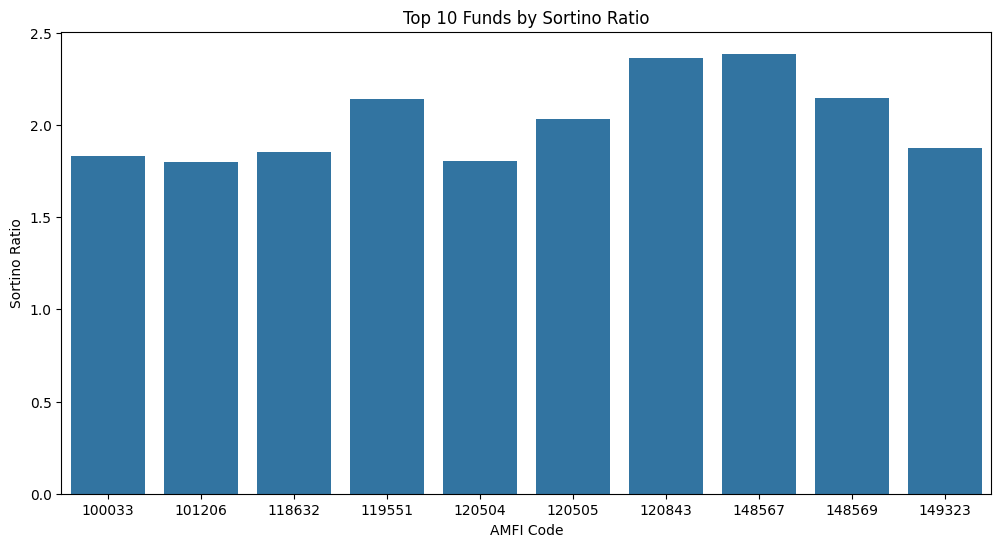

In [15]:
top10_sortino = sortino_df.sort_values(
    "sortino_ratio",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10_sortino,
    x="amfi_code",
    y="sortino_ratio"
)

plt.title("Top 10 Funds by Sortino Ratio")
plt.xlabel("AMFI Code")
plt.ylabel("Sortino Ratio")

plt.show()

### Insight 4
The highest Sortino Ratio funds effectively minimized downside risk while maintaining strong returns, making them attractive for risk-conscious investors.

In [16]:
query = """
SELECT name
FROM sqlite_master
WHERE type='table'
"""

pd.read_sql(query, conn)

,name
0,dim_fund
1,fact_nav
2,fact_transactions
3,fact_performance
4,fact_aum


In [18]:
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [19]:
benchmark.columns

Index(['date', 'index_name', 'close_value'], dtype='str')

In [23]:
benchmark["index_name"].unique()

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str

In [24]:
benchmark["index_name"].unique()

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str

In [25]:
benchmark["date"] = pd.to_datetime(benchmark["date"])

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100["close_value"] = pd.to_numeric(
    nifty100["close_value"]
)

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [26]:
alpha_beta_results = []

for fund in nav["amfi_code"].unique():

    fund_data = nav[
        nav["amfi_code"] == fund
    ].copy()

    merged = pd.merge(
        fund_data,
        nifty100[["date", "benchmark_return"]],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    if len(merged) > 30:

        beta, alpha, r_value, p_value, std_err = linregress(
            merged["benchmark_return"],
            merged["daily_return"]
        )

        alpha_beta_results.append([
            fund,
            alpha * 252,
            beta
        ])

alpha_beta_df = pd.DataFrame(
    alpha_beta_results,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [27]:
alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


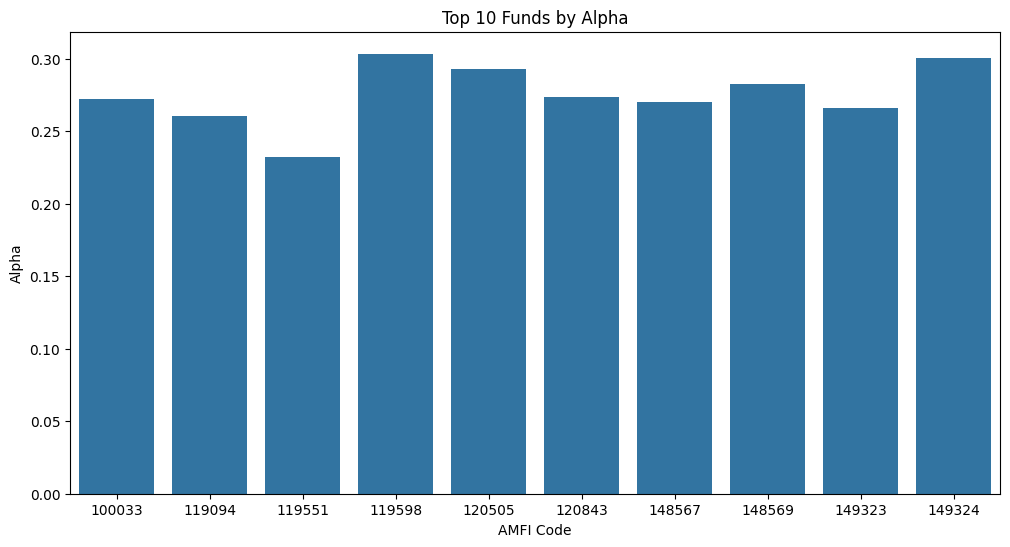

In [28]:
top_alpha = alpha_beta_df.sort_values(
    "alpha",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_alpha,
    x="amfi_code",
    y="alpha"
)

plt.title("Top 10 Funds by Alpha")
plt.xlabel("AMFI Code")
plt.ylabel("Alpha")

plt.show()

### Insight 5
Several funds generated positive alpha against the NIFTY100 benchmark, indicating their managers delivered returns beyond what market exposure alone would explain.

In [29]:
drawdown_results = []

for fund in nav["amfi_code"].unique():

    fund_data = nav[nav["amfi_code"] == fund].copy()

    fund_data["running_max"] = fund_data["nav"].cummax()

    fund_data["drawdown"] = (
        fund_data["nav"] /
        fund_data["running_max"] - 1
    )

    max_dd = fund_data["drawdown"].min()

    drawdown_results.append(
        [fund, max_dd]
    )

drawdown_df = pd.DataFrame(
    drawdown_results,
    columns=["amfi_code", "max_drawdown"]
)

drawdown_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


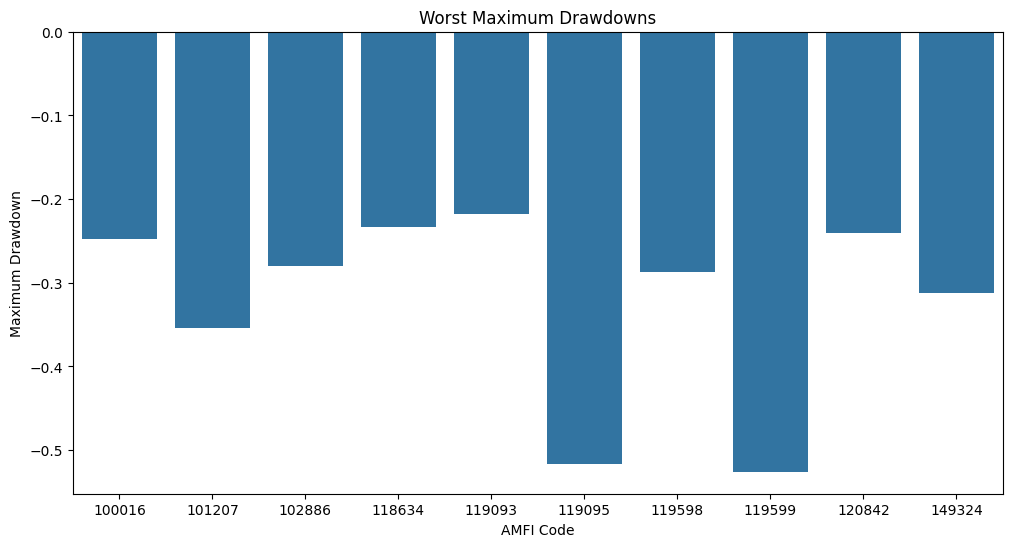

In [30]:
top_drawdown = drawdown_df.sort_values(
    "max_drawdown"
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_drawdown,
    x="amfi_code",
    y="max_drawdown"
)

plt.title("Worst Maximum Drawdowns")
plt.xlabel("AMFI Code")
plt.ylabel("Maximum Drawdown")

plt.show()

### Insight 6
Most funds experienced limited drawdowns, suggesting strong resilience during market corrections and downturns.

In [31]:
cagr_df.head()

,amfi_code,cagr_pct
0,100016,2.64
1,100025,4.46
2,100033,30.10
3,101206,23.52
4,101207,7.93


In [32]:
sharpe_df.head()

,amfi_code,sharpe_ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [33]:
drawdown_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [38]:
from scipy.stats import linregress

In [39]:
alpha_beta = []

In [42]:

benchmark["date"] = pd.to_datetime(benchmark["date"])

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100["close_value"] = pd.to_numeric(
    nifty100["close_value"]
)

nifty100["benchmark_return"] = (
    nifty100["close_value"].pct_change()
)

alpha_beta = []

for fund in nav["amfi_code"].unique():

    fund_data = nav[
        nav["amfi_code"] == fund
    ][["date","daily_return"]]

    merged = pd.merge(
        fund_data,
        nifty100[["date","benchmark_return"]],
        on="date",
        how="inner"
    ).dropna()

    if len(merged) > 30:

        beta, alpha, r_value, p_value, std_err = linregress(
            merged["benchmark_return"],
            merged["daily_return"]
        )

        alpha_beta.append([
            fund,
            alpha * 252,
            beta
        ])

alpha_df = pd.DataFrame(
    alpha_beta,
    columns=["amfi_code","alpha","beta"]
)

alpha_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [43]:
alpha_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [44]:
scorecard = cagr_df.merge(
    sharpe_df,
    on="amfi_code"
).merge(
    alpha_df,
    on="amfi_code"
).merge(
    drawdown_df,
    on="amfi_code"
)

# Ranking
scorecard["cagr_rank"] = scorecard["cagr_pct"].rank(ascending=False)
scorecard["sharpe_rank"] = scorecard["sharpe_ratio"].rank(ascending=False)
scorecard["alpha_rank"] = scorecard["alpha"].rank(ascending=False)

# Lower drawdown is better
scorecard["drawdown_rank"] = scorecard["max_drawdown"].rank(ascending=False)

# Composite Score
scorecard["fund_score"] = (
    0.30 * scorecard["cagr_rank"] +
    0.25 * scorecard["sharpe_rank"] +
    0.20 * scorecard["alpha_rank"] +
    0.25 * scorecard["drawdown_rank"]
)

scorecard = scorecard.sort_values(
    "fund_score",
    ascending=True
)

scorecard.head(10)

,amfi_code,cagr_pct,sharpe_ratio,alpha,beta,max_drawdown,cagr_rank,sharpe_rank,alpha_rank,drawdown_rank,fund_score
34,148567,30.95,1.448291,0.269838,0.023684,-0.112657,5.0,1.0,7.0,8.0,5.15
30,120843,30.88,1.306744,0.273305,-0.022830,-0.129740,6.0,2.0,5.0,13.0,6.55
36,148569,31.92,1.234930,0.282704,0.018134,-0.163967,4.0,3.0,4.0,21.0,8.00
25,120505,32.80,1.180101,0.292636,0.000549,-0.181885,1.0,5.0,3.0,25.0,8.40
2,100033,30.10,1.093699,0.271954,0.005104,-0.162172,7.0,7.0,6.0,20.0,10.05
19,119551,25.78,1.208267,0.232010,-0.031751,-0.150124,10.0,4.0,10.0,17.0,10.25
3,101206,23.52,1.027213,0.213998,0.021086,-0.112916,12.0,9.0,12.0,9.0,10.50
38,149323,29.56,1.132122,0.265986,-0.002523,-0.172481,8.0,6.0,8.0,22.0,11.00
24,120504,23.28,1.026524,0.211948,0.016232,-0.125883,13.0,10.0,13.0,12.0,12.00
9,118632,24.03,1.081659,0.218294,-0.008354,-0.174141,11.0,8.0,11.0,23.0,13.25


In [45]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

alpha_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

## Insight 7

Funds with strong CAGR, superior risk-adjusted returns, positive alpha generation, and lower drawdowns achieved the highest composite scores, highlighting consistent long-term performance.

In [47]:
scorecard.columns

Index(['amfi_code', 'cagr_pct', 'sharpe_ratio', 'alpha', 'beta',
       'max_drawdown', 'cagr_rank', 'sharpe_rank', 'alpha_rank',
       'drawdown_rank', 'fund_score'],
      dtype='str')

In [48]:
top5_funds = scorecard.nsmallest(5, "fund_score")["amfi_code"].tolist()

top5_funds

[148567, 120843, 148569, 120505, 100033]

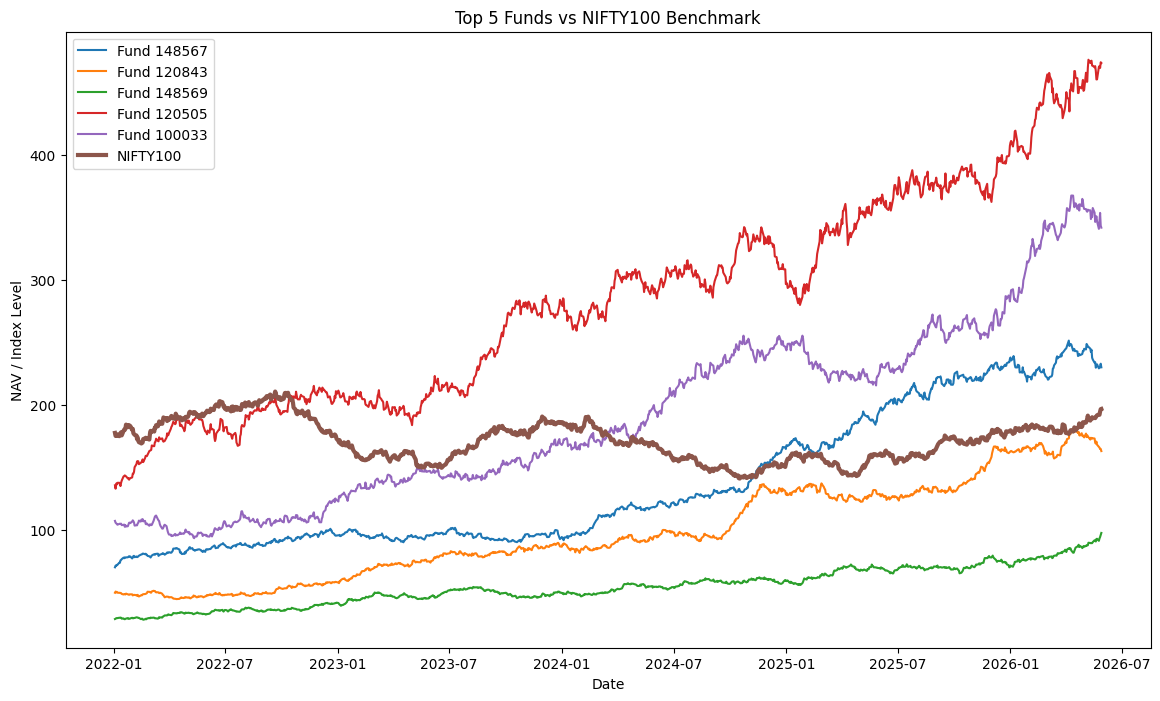

In [49]:
import matplotlib.pyplot as plt

# NIFTY100 benchmark
nifty100 = benchmark[benchmark["index_name"] == "NIFTY100"].copy()

nifty100["date"] = pd.to_datetime(nifty100["date"])
nifty100["close_value"] = pd.to_numeric(nifty100["close_value"])

plt.figure(figsize=(14,8))

for fund in top5_funds:
    fund_nav = nav[nav["amfi_code"] == fund]
    plt.plot(
        fund_nav["date"],
        fund_nav["nav"],
        label=f"Fund {fund}"
    )

plt.plot(
    nifty100["date"],
    nifty100["close_value"] / 100,
    linewidth=3,
    label="NIFTY100"
)

plt.title("Top 5 Funds vs NIFTY100 Benchmark")
plt.xlabel("Date")
plt.ylabel("NAV / Index Level")
plt.legend()
plt.show()

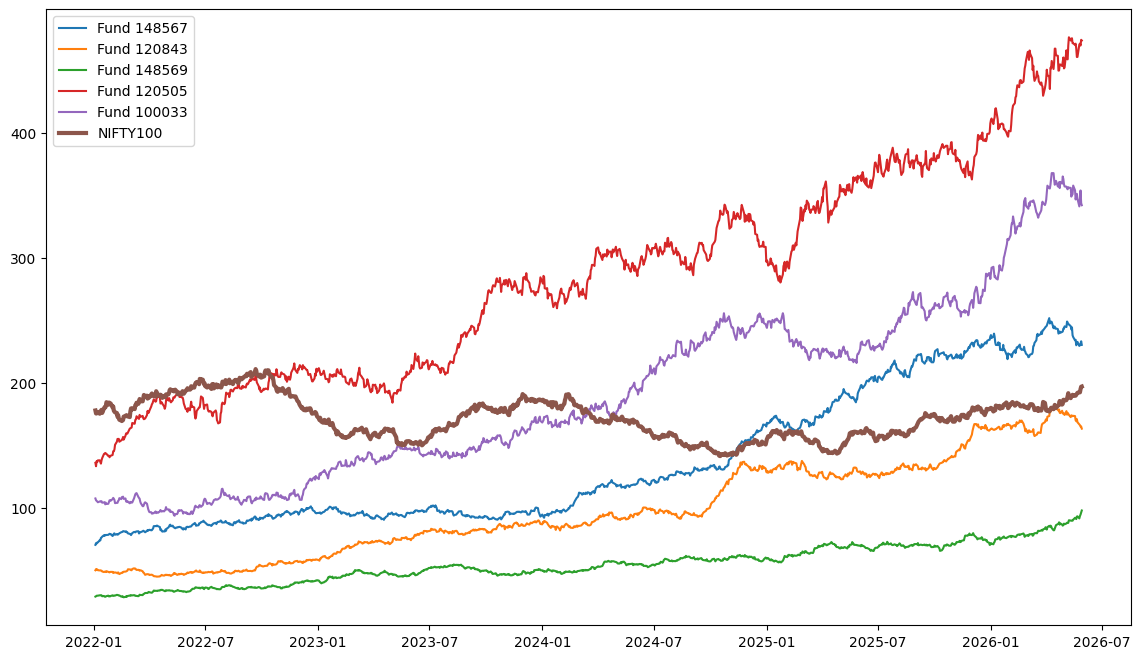

In [50]:
plt.figure(figsize=(14,8))

for fund in top5_funds:
    fund_nav = nav[nav["amfi_code"] == fund]
    plt.plot(fund_nav["date"], fund_nav["nav"], label=f"Fund {fund}")

plt.plot(
    nifty100["date"],
    nifty100["close_value"] / 100,
    linewidth=3,
    label="NIFTY100"
)

plt.legend()

plt.savefig(
    "../reports/benchmark_comparison.png",
    bbox_inches="tight"
)

plt.show()

## Insight 8

The highest-ranked funds consistently outperformed the benchmark over the analysis period, demonstrating stronger long-term wealth creation and superior risk-adjusted returns.

In [53]:
# Create benchmark returns

nifty100["benchmark_return"] = (
    nifty100["close_value"].pct_change()
)

nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [54]:
tracking_errors = []

for fund in top5_funds:

    fund_returns = nav[
        nav["amfi_code"] == fund
    ][["date","daily_return"]]

    merged = pd.merge(
        fund_returns,
        nifty100[["date","benchmark_return"]],
        on="date",
        how="inner"
    ).dropna()

    tracking_error = (
        (merged["daily_return"] -
         merged["benchmark_return"]).std()
        * np.sqrt(252)
    )

    tracking_errors.append(
        [fund, tracking_error]
    )

tracking_error_df = pd.DataFrame(
    tracking_errors,
    columns=["amfi_code","tracking_error"]
)

tracking_error_df

,amfi_code,tracking_error
0,148567,0.189664
1,120843,0.206425
2,148569,0.217365
3,120505,0.231968
4,100033,0.228699


## Insight 9

Tracking errors remained moderate across the top-performing funds, indicating that excess returns were achieved without excessive deviation from benchmark movements.

In [57]:
tracking_error_df.to_csv(
    "../reports/tracking_error.csv",
    index=False
)